# 📊 Combined Technical Indicators Engine

## 🔹 Overview
This project combines multiple popular **technical indicators** into one Python pipeline.  
The indicators are computed on either **real data** (via Yahoo Finance) or **synthetic data** (default, guaranteed to run).  

The goal is to build a reusable **technical analysis engine** that can:  
- Compute multiple indicators simultaneously.  
- Visualize them across multiple subplots.  
- Provide a **latest snapshot summary** of all indicator values.  

---

## 🔹 Indicators Included
1. **SMA (Simple Moving Average)**  
   Trend-following, smooths prices.  

2. **EMA (Exponential Moving Average)**  
   Trend-following, faster reaction to price.  

3. **RSI (Relative Strength Index)**  
   Momentum oscillator, overbought/oversold detection.  

4. **Bollinger Bands (BB)**  
   Volatility indicator with upper/lower bands around an MA.  

5. **MACD (Moving Average Convergence Divergence)**  
   Trend + momentum indicator with MACD line, Signal line, Histogram.  

6. **OBV (On-Balance Volume)**  
   Volume-based indicator measuring cumulative buying/selling pressure.  

7. **Stochastic Oscillator (%K, %D)**  
   Momentum oscillator comparing close vs recent high-low range.  

8. **ATR (Average True Range)**  
   Volatility indicator showing average price range.  

9. **Ichimoku Cloud**  
   Complete trading system: trend, momentum, and dynamic support/resistance.  


In [1]:
print("Hello World!")

Hello World!


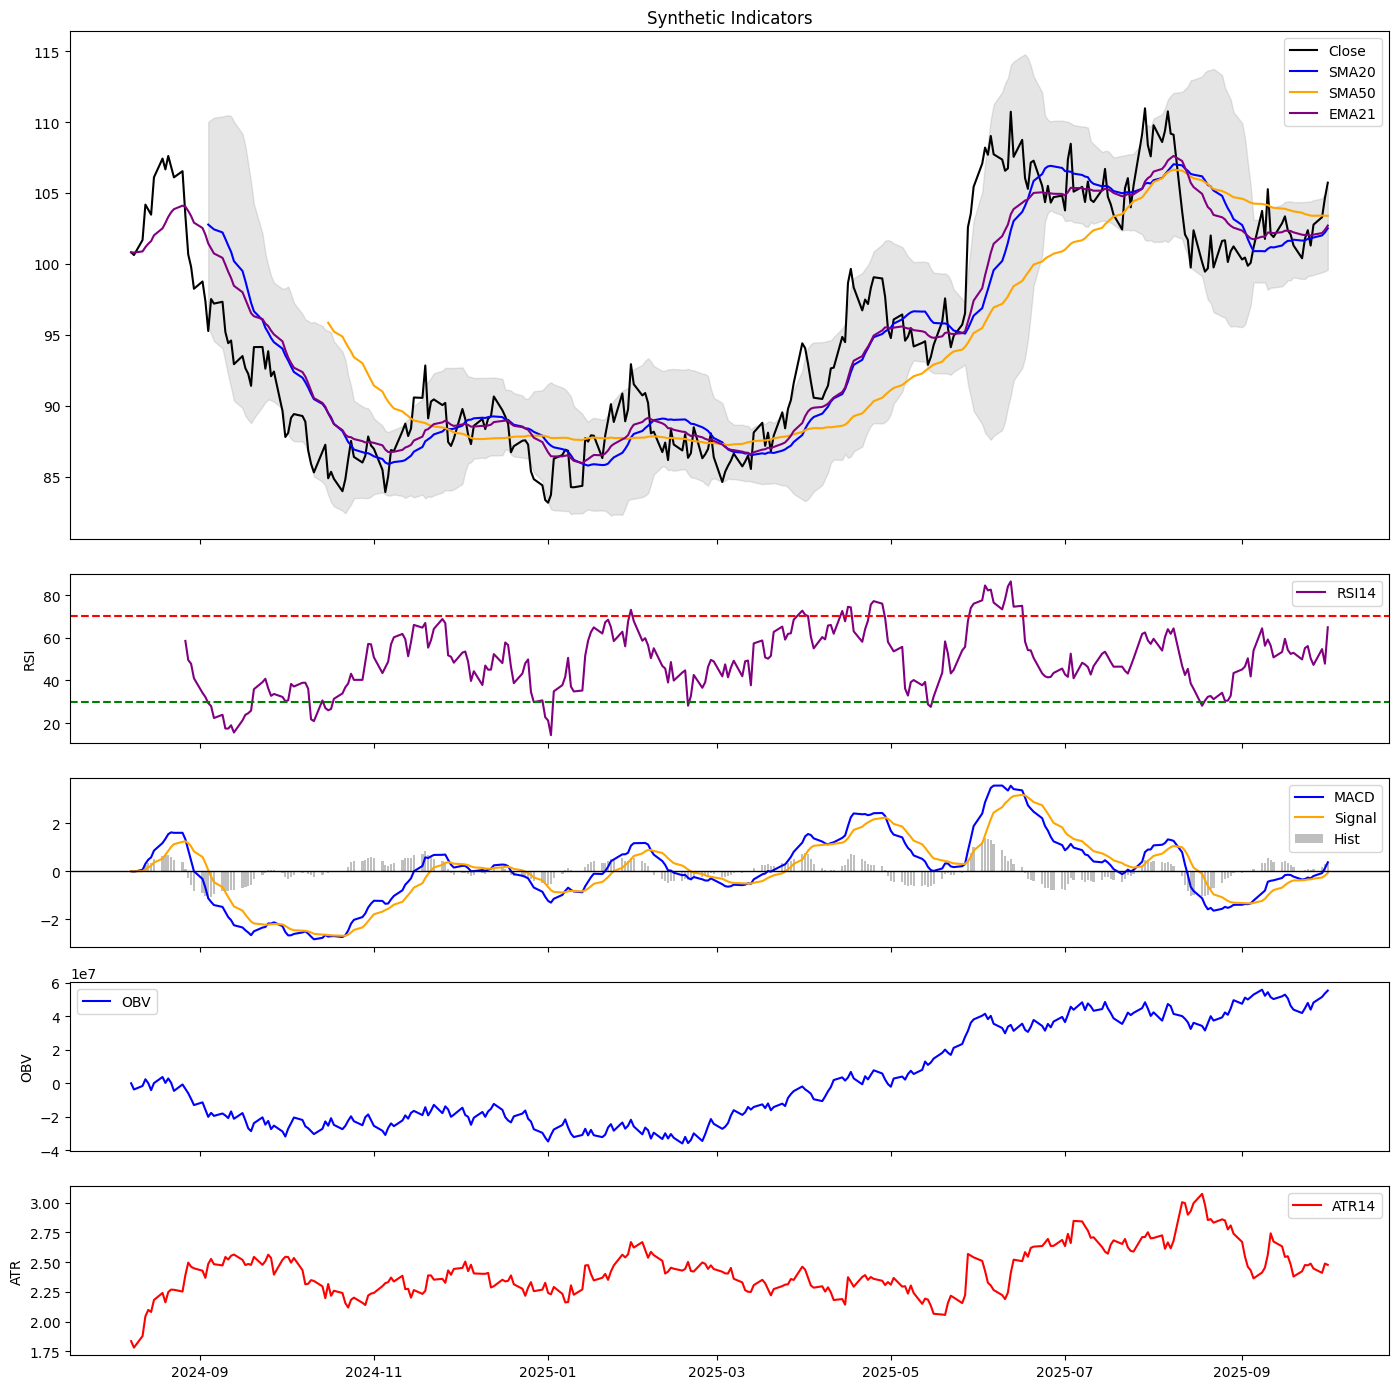


=== Latest Indicator Values ===
Close: 105.72
SMA20: 102.51 | SMA50: 103.38 | EMA21: 102.70
RSI14: 64.90
BB Upper: 105.43 | BB Lower: 99.59
MACD: 0.3684 | Signal: -0.0734 | Hist: 0.4418
OBV: 55370260.00
%K: 83.89 | %D: 72.97
ATR14: 2.4766
Tenkan: 103.14 | Kijun: 102.77
SenkouA: 103.22 | SenkouB: 105.51


In [2]:
# ==== Combined Technical Indicators Engine ====
# Includes SMA, EMA, RSI, Bollinger Bands, MACD, OBV, Stochastic, ATR, Ichimoku

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
RUN_MODE   = "synthetic"   # "synthetic" or "yfinance"
TICKER     = "AAPL"        # if RUN_MODE="yfinance"
PERIOD     = "1y"
INTERVAL   = "1d"
# -------------------------

# === Helper: Load Data ===
if RUN_MODE == "yfinance":
    try:
        import yfinance as yf
        df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=False, progress=False)
        if df.empty:
            raise RuntimeError("No data returned")
        df.index = pd.to_datetime(df.index)
        title = f"{TICKER} Indicators"
    except Exception as e:
        print("Falling back to synthetic data:", e)
        RUN_MODE = "synthetic"

if RUN_MODE == "synthetic":
    np.random.seed(42)
    n = 300
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    mu, sigma, dt = 0.10, 0.25, 1/252
    z = np.random.normal(size=n)
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    high = close * (1 + np.random.uniform(0.001,0.02,size=n))
    low  = close * (1 - np.random.uniform(0.001,0.02,size=n))
    volume = pd.Series(np.random.randint(1e6,5e6,size=n), index=dates, name="Volume")
    df = pd.DataFrame({"High":high,"Low":low,"Close":close,"Volume":volume})
    title = "Synthetic Indicators"

# === 1. SMA & EMA ===
df["SMA20"] = df["Close"].rolling(20).mean()
df["SMA50"] = df["Close"].rolling(50).mean()
df["EMA21"] = df["Close"].ewm(span=21, adjust=False).mean()

# === 2. RSI ===
delta = df["Close"].diff()
gain = np.where(delta>0, delta, 0)
loss = np.where(delta<0, -delta, 0)
roll_up = pd.Series(gain, index=df.index).rolling(14).mean()
roll_down = pd.Series(loss, index=df.index).rolling(14).mean()
RS = roll_up / roll_down.replace(0,np.nan)
df["RSI14"] = 100 - (100/(1+RS))

# === 3. Bollinger Bands ===
mid = df["Close"].rolling(20).mean()
std = df["Close"].rolling(20).std(ddof=0)
df["BB_MID"] = mid
df["BB_UP"]  = mid + 2*std
df["BB_LOW"] = mid - 2*std

# === 4. MACD ===
ema_fast = df["Close"].ewm(span=12, adjust=False).mean()
ema_slow = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema_fast - ema_slow
df["MACD_SIG"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_HIST"] = df["MACD"] - df["MACD_SIG"]

# === 5. OBV ===
obv = [0]
for i in range(1,len(df)):
    if df["Close"].iloc[i] > df["Close"].iloc[i-1]:
        obv.append(obv[-1] + df["Volume"].iloc[i])
    elif df["Close"].iloc[i] < df["Close"].iloc[i-1]:
        obv.append(obv[-1] - df["Volume"].iloc[i])
    else:
        obv.append(obv[-1])
df["OBV"] = obv

# === 6. Stochastic Oscillator ===
low14 = df["Low"].rolling(14).min()
high14 = df["High"].rolling(14).max()
df["%K"] = 100 * (df["Close"] - low14) / (high14 - low14)
df["%D"] = df["%K"].rolling(3).mean()

# === 7. ATR ===
prev_close = df["Close"].shift(1)
tr1 = df["High"] - df["Low"]
tr2 = (df["High"] - prev_close).abs()
tr3 = (df["Low"] - prev_close).abs()
true_range = pd.concat([tr1,tr2,tr3], axis=1).max(axis=1)
df["ATR14"] = true_range.ewm(alpha=1/14, adjust=False).mean()

# === 8. Ichimoku ===
TENKAN, KIJUN, SENKOU, SHIFT = 9, 26, 52, 26
df["Tenkan"] = (df["High"].rolling(TENKAN).max() + df["Low"].rolling(TENKAN).min())/2
df["Kijun"]  = (df["High"].rolling(KIJUN).max() + df["Low"].rolling(KIJUN).min())/2
df["SenkouA"]= ((df["Tenkan"]+df["Kijun"])/2).shift(SHIFT)
df["SenkouB"]= ((df["High"].rolling(SENKOU).max() + df["Low"].rolling(SENKOU).min())/2).shift(SHIFT)
df["Chikou"] = df["Close"].shift(-SHIFT)

# === Plot some key indicators ===
fig, axes = plt.subplots(5,1,figsize=(14,14), sharex=True,
                         gridspec_kw={'height_ratios':[3,1,1,1,1]})

# Price + SMA/EMA + BB
axes[0].plot(df.index, df["Close"], label="Close", color="black")
axes[0].plot(df.index, df["SMA20"], label="SMA20", color="blue")
axes[0].plot(df.index, df["SMA50"], label="SMA50", color="orange")
axes[0].plot(df.index, df["EMA21"], label="EMA21", color="purple")
axes[0].fill_between(df.index, df["BB_LOW"], df["BB_UP"], color="gray", alpha=0.2)
axes[0].set_title(title)
axes[0].legend()

# RSI
axes[1].plot(df.index, df["RSI14"], label="RSI14", color="purple")
axes[1].axhline(70, color="red", linestyle="--")
axes[1].axhline(30, color="green", linestyle="--")
axes[1].set_ylabel("RSI")
axes[1].legend()

# MACD
axes[2].plot(df.index, df["MACD"], label="MACD", color="blue")
axes[2].plot(df.index, df["MACD_SIG"], label="Signal", color="orange")
axes[2].bar(df.index, df["MACD_HIST"], label="Hist", color="gray", alpha=0.5)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].legend()

# OBV
axes[3].plot(df.index, df["OBV"], label="OBV", color="blue")
axes[3].set_ylabel("OBV")
axes[3].legend()

# ATR
axes[4].plot(df.index, df["ATR14"], label="ATR14", color="red")
axes[4].set_ylabel("ATR")
axes[4].legend()

plt.tight_layout()
plt.show()

# === Summary of last row ===
latest = df.iloc[-1]
print("\n=== Latest Indicator Values ===")
print(f"Close: {latest['Close']:.2f}")
print(f"SMA20: {latest['SMA20']:.2f} | SMA50: {latest['SMA50']:.2f} | EMA21: {latest['EMA21']:.2f}")
print(f"RSI14: {latest['RSI14']:.2f}")
print(f"BB Upper: {latest['BB_UP']:.2f} | BB Lower: {latest['BB_LOW']:.2f}")
print(f"MACD: {latest['MACD']:.4f} | Signal: {latest['MACD_SIG']:.4f} | Hist: {latest['MACD_HIST']:.4f}")
print(f"OBV: {latest['OBV']:.2f}")
print(f"%K: {latest['%K']:.2f} | %D: {latest['%D']:.2f}")
print(f"ATR14: {latest['ATR14']:.4f}")
print(f"Tenkan: {latest['Tenkan']:.2f} | Kijun: {latest['Kijun']:.2f}")
print(f"SenkouA: {df['SenkouA'].dropna().iloc[-1]:.2f} | SenkouB: {df['SenkouB'].dropna().iloc[-1]:.2f}")
